# Step 3: 태그 기반 캡션 자동 생성
- `space_mood_tag .csv` (id, emotion, visual, space) 읽기
- 태그별 문구 사전으로 조합 → caption 컬럼 추가
- LoRA 학습용 CSV 저장

In [1]:
import random
import pandas as pd

SEED = 42
random.seed(SEED)

CSV_INPUT  = "/home/piai/b2/PBA_AI_Project/modeling/image/space_mood_tag .csv"
CSV_OUTPUT = "/home/piai/b2/PBA_AI_Project/modeling/image/space_mood_tag_captioned.csv"

## 1. 태그별 문구 사전

In [2]:
# 같은 태그라도 여러 표현을 등록해서 캡션 다양성 확보
EMOTION_PHRASES = {
    "cozy": [
        "cozy atmosphere",
        "warm and inviting ambiance",
        "comfortable homey feel",
        "snug and relaxed interior",
    ],
    "chic": [
        "chic and stylish aesthetic",
        "sophisticated and elegant design",
        "refined modern atmosphere",
        "sleek upscale interior",
    ],
    "lively": [
        "lively and energetic vibe",
        "vibrant party atmosphere",
        "dynamic and festive energy",
        "upbeat celebratory setting",
    ],
}

VISUAL_PHRASES = {
    "cool": [
        "cool-toned blue lighting",
        "crisp cool color palette",
        "icy blue-white ambiance",
    ],
    "warm": [
        "warm golden lighting",
        "amber and orange warm tones",
        "soft warm-toned glow",
    ],
    "bright": [
        "bright and well-lit space",
        "airy luminous interior",
        "clear high-key lighting",
    ],
    "dark": [
        "dim moody atmospheric lighting",
        "dark low-key ambiance",
        "shadowy intimate lighting",
    ],
}

SPACE_PHRASES = {
    "spacious": [
        "spacious open layout",
        "expansive roomy interior",
        "wide open party space",
    ],
    "compact": [
        "compact cozy gathering space",
        "small intimate area",
        "enclosed snug setting",
    ],
    "private": [
        "private secluded party room",
        "intimate enclosed setting",
        "exclusive private interior",
    ],
}

SUFFIX = "home party interior, indoor gathering space"

print("emotion tags:", list(EMOTION_PHRASES.keys()))
print("visual  tags:", list(VISUAL_PHRASES.keys()))
print("space   tags:", list(SPACE_PHRASES.keys()))

emotion tags: ['cozy', 'chic', 'lively']
visual  tags: ['cool', 'warm', 'bright', 'dark']
space   tags: ['spacious', 'compact', 'private']


## 2. CSV 로드 & 라벨 검증

In [3]:
df = pd.read_csv(CSV_INPUT)
print(f"rows: {len(df)}")
display(df.head())

# 소문자 정규화
for col in ["emotion", "visual", "space"]:
    df[col] = df[col].str.strip().str.lower()

# 유효하지 않은 태그 확인
bad_emo = ~df["emotion"].isin(EMOTION_PHRASES)
bad_vis = ~df["visual"].isin(VISUAL_PHRASES)
bad_spa = ~df["space"].isin(SPACE_PHRASES)

for col, mask in [("emotion", bad_emo), ("visual", bad_vis), ("space", bad_spa)]:
    if mask.any():
        print(f"[경고] 알 수 없는 {col} 태그: {df.loc[mask, col].unique()}")

bad = bad_emo | bad_vis | bad_spa
if bad.any():
    print(f"→ {bad.sum()}행 제거")
    df = df[~bad].reset_index(drop=True)
else:
    print("모든 태그 정상")

rows: 294


,id,emotion,visual,space
0,0,cozy,warm,private
1,1,chic,cool,compact
2,2,lively,cool,private
3,3,lively,warm,compact
4,4,cozy,warm,spacious


모든 태그 정상


## 3. 클래스 분포 확인

/tmp/ipykernel_2525477/3266823921.py:12: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2525477/3266823921.py:12: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2525477/3266823921.py:12: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2525477/3266823921.py:12: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2525477/3266823921.py:12: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
/home/piai/anaconda3/envs/test_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/envs/test_env/lib/python3.10/site-packages/IPython/core/pylabt

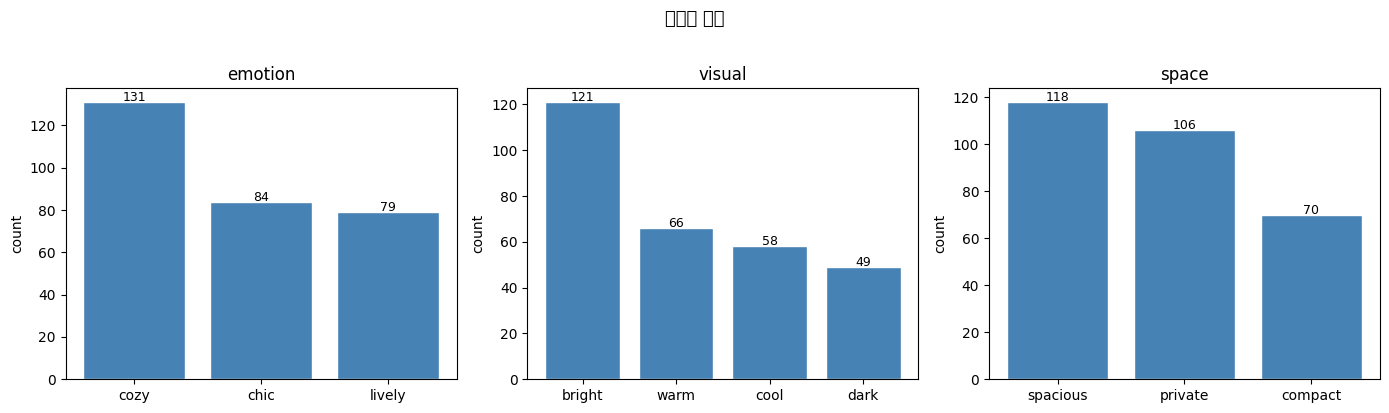

emotion  visual  space   
lively   bright  spacious    28
chic     bright  spacious    23
cozy     warm    private     19
lively   bright  compact     16
chic     dark    private     15
cozy     cool    private     15
         bright  spacious    15
         warm    spacious    15
                 compact     13
         bright  private     13
                 compact     10
chic     cool    spacious    10
cozy     cool    compact      9
chic     cool    private      9
cozy     dark    private      9
lively   bright  private      8
chic     bright  private      7
lively   warm    spacious     7
chic     dark    spacious     7
         warm    private      7
dtype: int64


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["emotion", "visual", "space"]):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)
plt.suptitle("클래스 분포", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(df[["emotion", "visual", "space"]].value_counts().head(20))

## 4. 캡션 생성

In [5]:
def build_caption(emotion, visual, space):
    emo_p = random.choice(EMOTION_PHRASES[emotion])
    vis_p = random.choice(VISUAL_PHRASES[visual])
    spa_p = random.choice(SPACE_PHRASES[space])
    return f"{emo_p}, {vis_p}, {spa_p}, {SUFFIX}"

df["tags"]    = df["emotion"] + ", " + df["visual"] + ", " + df["space"]
df["caption"] = df.apply(lambda r: build_caption(r["emotion"], r["visual"], r["space"]), axis=1)

display(df[["id", "emotion", "visual", "space", "tags", "caption"]].head(10))

,id,emotion,visual,space,tags,caption
0,0,cozy,warm,private,"cozy, warm, private","cozy atmosphere, warm golden lighting, exclusi..."
1,1,chic,cool,compact,"chic, cool, compact","refined modern atmosphere, cool-toned blue lig..."
2,2,lively,cool,private,"lively, cool, private","vibrant party atmosphere, icy blue-white ambia..."
3,3,lively,warm,compact,"lively, warm, compact","lively and energetic vibe, soft warm-toned glo..."
4,4,cozy,warm,spacious,"cozy, warm, spacious","cozy atmosphere, warm golden lighting, spaciou..."
5,5,lively,bright,private,"lively, bright, private","vibrant party atmosphere, bright and well-lit ..."
6,6,lively,bright,spacious,"lively, bright, spacious","lively and energetic vibe, clear high-key ligh..."
7,7,cozy,warm,compact,"cozy, warm, compact","snug and relaxed interior, warm golden lightin..."
8,8,chic,warm,private,"chic, warm, private","refined modern atmosphere, warm golden lightin..."
9,9,cozy,warm,spacious,"cozy, warm, spacious","snug and relaxed interior, amber and orange wa..."


## 5. 조합별 캡션 예시 출력

In [6]:
print("태그 조합 → 캡션 예시 (각 조합당 2개)\n")
for emo in EMOTION_PHRASES:
    for vis in VISUAL_PHRASES:
        for spa in SPACE_PHRASES:
            c1 = build_caption(emo, vis, spa)
            c2 = build_caption(emo, vis, spa)
            print(f"[{emo}+{vis}+{spa}]")
            print(f"  {c1}")
            print(f"  {c2}")

태그 조합 → 캡션 예시 (각 조합당 2개)

[cozy+cool+spacious]
  snug and relaxed interior, crisp cool color palette, spacious open layout, home party interior, indoor gathering space
  warm and inviting ambiance, crisp cool color palette, wide open party space, home party interior, indoor gathering space
[cozy+cool+compact]
  comfortable homey feel, icy blue-white ambiance, small intimate area, home party interior, indoor gathering space
  cozy atmosphere, icy blue-white ambiance, compact cozy gathering space, home party interior, indoor gathering space
[cozy+cool+private]
  comfortable homey feel, icy blue-white ambiance, exclusive private interior, home party interior, indoor gathering space
  warm and inviting ambiance, crisp cool color palette, private secluded party room, home party interior, indoor gathering space
[cozy+warm+spacious]
  warm and inviting ambiance, soft warm-toned glow, spacious open layout, home party interior, indoor gathering space
  comfortable homey feel, warm golden lighti

## 6. CSV 저장

In [7]:
df.to_csv(CSV_OUTPUT, index=False, encoding="utf-8-sig")
print(f"저장 완료: {CSV_OUTPUT}")
print(f"총 {len(df)}행 | 컬럼: {list(df.columns)}")
display(df.tail(5))

저장 완료: /home/piai/b2/PBA_AI_Project/modeling/image/space_mood_tag_captioned.csv
총 294행 | 컬럼: ['id', 'emotion', 'visual', 'space', 'tags', 'caption']


,id,emotion,visual,space,tags,caption
289,289,lively,bright,compact,"lively, bright, compact","vibrant party atmosphere, airy luminous interi..."
290,290,cozy,cool,private,"cozy, cool, private","cozy atmosphere, cool-toned blue lighting, pri..."
291,291,chic,bright,spacious,"chic, bright, spacious","sophisticated and elegant design, clear high-k..."
292,292,cozy,dark,compact,"cozy, dark, compact","warm and inviting ambiance, dim moody atmosphe..."
293,293,cozy,bright,spacious,"cozy, bright, spacious","snug and relaxed interior, clear high-key ligh..."
